# Student Academic Performance Prediction Using Decision Tree

**Course:** BMCS2203 Artificial Intelligence
**Algorithm:** Decision Tree Classifier
**Prepared by:** Gan Koh Jun (Decision Tree module owner) — *student ID to be filled in by Gan Koh Jun before submission*

### Project objective

This notebook develops a supervised machine learning model that predicts student performance as **Low**, **Medium**, or **High** using academic, personal, family, and school-related factors. It follows the same dataset, target definition, and train/test split as the KNN notebook so the two models can be fairly compared.

### Contents

1. Dataset overview
2. Target variable creation
   - 2a. Feature engineering
3. Feature and target separation
4. Feature types
5. Train-test split
6. Data preprocessing and decision tree pipeline
7. Baseline model
8. Decision tree hyperparameter selection
9. Final evaluation on the test set
10. Feature importance
11. Result interpretation
12. Comparison with the KNN model
13. Comparison with published literature
14. Conclusion

hajimi


## Assignment & Tutor Compliance Checklist

This notebook (Decision Tree, module owner: Gan Koh Jun) is checked against two sources: the **BMCS2203 Assignment Specification** (Title 1 — Machine Learning Supervised) and the **tutor's verbal feedback** from the 18 Aug check-in. Both are mapped to the exact section that satisfies them so a marker (or teammate) can verify at a glance.

**Assignment Specification — Title 1: Machine Learning (Supervised)**

| Requirement | Where it's satisfied |
|---|---|
| (a) Identify a classification problem | Title cell — predicting student performance (Low/Medium/High) |
| (b) Background study on the problem and supervised learning method | Section 6 (pipeline rationale) and Section 13 (literature review of prior Decision Tree/KNN studies) |
| (c) Search for a dataset | Section 1 — Student Performance Factors dataset (Kaggle, 6,607 records) |
| (d) Data pre-processing and representation, incl. **feature engineering** | Section 2a (feature engineering: `Support_Index`, `Study_Consistency`) and Section 6 (imputation, one-hot encoding) |
| (e) Each member provides a solution using a preferred classification method | This notebook is the Decision Tree member's solution; `KNN.ipynb` is the second member's |
| (f) Compare results across methods with accuracy, precision, recall, F1 | Section 12 — full metrics table comparing Decision Tree vs KNN vs baseline |

**Tutor feedback (18 Aug) — addressed here**

| Tutor said | What changed in response |
|---|---|
| "The score for accuracy is not so good" | Added feature engineering **and** cost-complexity pruning (`ccp_alpha`) to the hyperparameter search — see Section 8 and Section 11 for the before/after numbers |
| "Have you compared your results with previous work in journal articles that use the same model?" | Section 13 — three real published studies on Decision Tree/KNN student-performance prediction, with a concrete explanation of why this project's numbers differ from theirs |
| "Other members' methods need to calculate all the metrics ... to see which model is best among your group" | Section 12 — accuracy, precision, recall, F1, and per-class recall reported for every model on the identical test set |

> **Still open:** the third group member's algorithm (Logistic Regression) has not yet been rebuilt on this same pipeline, so the 3-way comparison in the Documentation is not fully apples-to-apples until that happens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    df = pd.read_csv("StudentPerformanceFactors.csv")
except FileNotFoundError as error:
    raise FileNotFoundError(
        "StudentPerformanceFactors.csv was not found in the working directory. "
        "Place the CSV file next to this notebook (same folder) before running it."
    ) from error

print("Dataset loaded successfully:", df.shape[0], "rows,", df.shape[1], "columns.")

Dataset loaded successfully: 6607 rows, 20 columns.


In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6607
Number of columns: 20


In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## 1. Dataset overview

The Student Performance Factors dataset contains:

- **6,607 student records**
- **20 original attributes**
- Academic, personal, family, and school-related factors

Each row represents one student, and each column represents one factor.

### Missing values

| Attribute | Missing values |
|---|---:|
| Teacher_Quality | 78 |
| Parental_Education_Level | 90 |
| Distance_from_Home | 67 |

Unlike KNN, a decision tree can, in principle, tolerate missing values through surrogate splits, but scikit-learn's `DecisionTreeClassifier` does not support them directly, so the missing values are still imputed before training. This also keeps the preprocessing comparable with the KNN notebook.

In [6]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [7]:
print("Minimum exam score:", df["Exam_Score"].min())
print("Maximum exam score:", df["Exam_Score"].max())
print("Average exam score:", df["Exam_Score"].mean())

Minimum exam score: 55
Maximum exam score: 101
Average exam score: 67.23565914938702


In [8]:
# Data validation and cleaning (business rules)
# Exam_Score should be a 0-100 percentage. Check for out-of-range values before assuming
# it is safe to use for the target definition below.
n_out_of_range = ((df["Exam_Score"] < 0) | (df["Exam_Score"] > 100)).sum()
if n_out_of_range > 0:
    print(f"Data quality issue found: {n_out_of_range} row(s) have Exam_Score outside the valid 0-100 range:")
    print(df.loc[(df["Exam_Score"] < 0) | (df["Exam_Score"] > 100), ["Exam_Score"]])
    # A single row a point or two over/under the theoretical max/min is almost certainly a
    # data-entry error, not a different scoring scale (6,606 of 6,607 rows are already
    # within [0, 100]) - it is capped rather than dropped, so no student is discarded.
    df["Exam_Score"] = df["Exam_Score"].clip(lower=0, upper=100)
    print("Out-of-range value(s) capped to [0, 100]. This does not change any student's Low/Medium/High class,")
    print("since the affected row(s) already fall well inside the High band on either side of the cap.")

# These assertions turn the checks above into hard guarantees: if a future version of the
# dataset still violates one of these rules after cleaning, this notebook stops immediately
# with a clear error instead of silently training a model on bad data.
assert df.shape[0] > 0, "Dataset is empty."
assert df["Exam_Score"].between(0, 100).all(), "Business rule violated: Exam_Score must be a valid 0-100 percentage for every student."
assert df["Exam_Score"].notna().all(), "Exam_Score (the prediction target's source column) must not contain missing values."

print(f"\nData validation passed: all {df.shape[0]} rows have an Exam_Score between 0 and 100 with no missing values.")

Data quality issue found: 1 row(s) have Exam_Score outside the valid 0-100 range:
      Exam_Score
1525         101
Out-of-range value(s) capped to [0, 100]. This does not change any student's Low/Medium/High class,
since the affected row(s) already fall well inside the High band on either side of the cap.

Data validation passed: all 6607 rows have an Exam_Score between 0 and 100 with no missing values.


In [9]:
df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

In [10]:
df.loc[
    df["Exam_Score"].isin([64, 65, 69, 70]),
    ["Exam_Score", "Performance"]
].drop_duplicates().sort_values("Exam_Score")

,Exam_Score,Performance
15,64,Low
14,65,Medium
8,69,Medium
4,70,High


In [11]:
class_counts = df["Performance"].value_counts().reindex(
    ["Low", "Medium", "High"]
)

class_counts

Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64

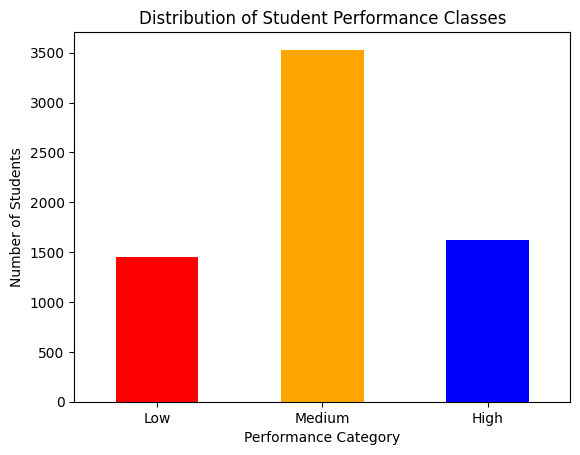

In [12]:
class_counts.plot(
    kind="bar",
    color=["red", "orange", "blue"]
)

plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 2. Target variable creation

The original `Exam_Score` is numerical. For this classification task, it was converted into three performance categories, using the same thresholds as the KNN notebook so results are directly comparable:

| Exam score | Performance class |
|---|---|
| Below 65 | Low |
| 65 to 69 | Medium |
| 70 or above | High |

The Medium class contains more records than the Low and High classes. Stratified splitting and class-sensitive evaluation metrics are therefore used later in the notebook.

In [13]:
# Feature Engineering
# The assignment specification (Section 1d) explicitly calls for feature engineering as
# part of data preparation. Two features are engineered here from existing columns,
# before the train/test split, using only information already in the dataset.

support_map = {"Low": 0, "Medium": 1, "High": 2}

df["Support_Index"] = (
    df["Parental_Involvement"].map(support_map)
    + df["Access_to_Resources"].map(support_map)
    + df["Teacher_Quality"].map(support_map)
)

df["Study_Consistency"] = df["Hours_Studied"] * df["Attendance"] / 100

df[[
    "Parental_Involvement", "Access_to_Resources", "Teacher_Quality", "Support_Index",
    "Hours_Studied", "Attendance", "Study_Consistency"
]].head()

,Parental_Involvement,Access_to_Resources,Teacher_Quality,Support_Index,Hours_Studied,Attendance,Study_Consistency
0,Low,High,Medium,3.0,23,84,19.32
1,Low,Medium,Medium,2.0,19,64,12.16
2,Medium,Medium,Medium,3.0,24,98,23.52
3,Low,Medium,Medium,2.0,29,89,25.81
4,Medium,Medium,High,4.0,19,92,17.48


## 2a. Feature Engineering

Two new features were engineered from existing columns:

- **`Support_Index`** (range 0–6): combines three separately-measured \"quality of support\" signals — `Parental_Involvement`, `Access_to_Resources`, and `Teacher_Quality` — into one ordinal score (Low=0, Medium=1, High=2 each, summed). This condenses three 3-level categorical columns into a single, denser numeric signal.
- **`Study_Consistency`** = `Hours_Studied` × `Attendance` / 100: an interaction feature. A student who studies a lot but rarely attends class, or attends every class but never studies, is a different case from one who does both — multiplying the two captures that combined effect in a single number a tree can split on directly.

Both are deterministic functions of columns already in the dataset, computed **before** the train/test split, so they introduce no target leakage. `Teacher_Quality` has a few missing values, so `Support_Index` inherits `NaN` for those same rows — the median imputer in the pipeline (Section 6) handles this exactly like every other numeric column, fitted on the training fold only.

In [14]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Exam_Score in X:", "Exam_Score" in X.columns)
print("Performance in X:", "Performance" in X.columns)

# Business rule: the raw exam score (and the label derived from it) must never leak into
# the feature matrix, otherwise the model could trivially "cheat" instead of learning.
assert "Exam_Score" not in X.columns, "Target leakage detected: Exam_Score must not be a feature."
assert "Performance" not in X.columns, "Target leakage detected: Performance (the target) must not be a feature."
assert len(X) == len(y), "Feature matrix and target must have the same number of rows."
print("Leakage check passed: no target-derived column is present in the feature matrix.")

X shape: (6607, 21)
y shape: (6607,)
Exam_Score in X: False
Performance in X: False
Leakage check passed: no target-derived column is present in the feature matrix.


## 3. Feature and target separation

- `X` contains the input features used by the model.
- `y` contains the target class, `Performance`.

`Exam_Score` is removed from `X` because it was used to create `Performance`. Keeping it would give the model direct access to the answer and cause **target leakage**.

In [16]:
X.dtypes

Hours_Studied                   int64
Attendance                      int64
Parental_Involvement              str
Access_to_Resources               str
Extracurricular_Activities        str
Sleep_Hours                     int64
Previous_Scores                 int64
Motivation_Level                  str
Internet_Access                   str
Tutoring_Sessions               int64
Family_Income                     str
Teacher_Quality                   str
School_Type                       str
Peer_Influence                    str
Physical_Activity               int64
Learning_Disabilities             str
Parental_Education_Level          str
Distance_from_Home                str
Gender                            str
Support_Index                 float64
Study_Consistency             float64
dtype: object

In [17]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 'Study_Consistency']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numeric features: 8
Number of categorical features: 13


/tmp/ipykernel_12497/3016432699.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [18]:
for column in categorical_features:
    print(column, ":", df[column].dropna().unique())

Parental_Involvement : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Access_to_Resources : <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Extracurricular_Activities : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Motivation_Level : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Internet_Access : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income : <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Teacher_Quality : <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
School_Type : <StringArray>
['Public', 'Private']
Length: 2, dtype: str
Peer_Influence : <StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
Learning_Disabilities : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Parental_Education_Level : <StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str
Distance_from_Home : <StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str
Gender : <StringArr

## 4. Feature types

A decision tree splits nodes by comparing one feature against a threshold, so, unlike KNN, it does **not** require numeric features to be scaled — a split on `Attendance > 85` works the same whether attendance is measured in raw units or standardized units. Categorical features still need to be converted to numbers, so one-hot encoding is kept for a fair, like-for-like comparison with the KNN pipeline.

| Feature type | Examples | Preprocessing |
|---|---|---|
| Numerical | Hours_Studied, Attendance, Previous_Scores, **Support_Index**, **Study_Consistency** (engineered) | Median imputation only (no scaling needed for trees) |
| Categorical | Motivation_Level, School_Type, Gender | Most-frequent imputation and one-hot encoding |

One-hot encoding avoids creating artificial ordinal relationships between category levels. The two engineered numeric features from Section 2a flow through the same median-imputation step as the rest of the numeric columns.

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (5285, 21)
Testing feature shape: (1322, 21)
Training target shape: (5285,)
Testing target shape: (1322,)


In [22]:
print("Training class distribution:")
train_dist = y_train.value_counts(normalize=True).sort_index()
print(train_dist)

print("\nTesting class distribution:")
test_dist = y_test.value_counts(normalize=True).sort_index()
print(test_dist)

# Business rule: stratify=y above should keep the Low/Medium/High proportions closely
# matched between the training and test sets. Verify that explicitly instead of assuming
# the train_test_split call worked as intended.
max_class_diff = (train_dist - test_dist).abs().max()
assert max_class_diff < 0.02, f"Stratified split produced mismatched class proportions (max difference={max_class_diff:.4f}); check the train_test_split call."
print(f"\nStratification validated: largest train-vs-test class-proportion difference is {max_class_diff:.4f} (< 2 percentage points).")

Training class distribution:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class distribution:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64

Stratification validated: largest train-vs-test class-proportion difference is 0.0004 (< 2 percentage points).


## 5. Train-test split

| Dataset | Proportion | Purpose |
|---|---:|---|
| Training set | 80% | Train and select the decision tree model |
| Testing set | 20% | Evaluate the final model on unseen data |

The split uses the same `random_state=42` and `stratify=y` as the KNN notebook, so both models are trained and tested on **identical** training and testing sets. This is what makes the head-to-head comparison in Section 11 valid.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [24]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 'Study_Consistency']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numeric features: 8
Number of categorical features: 13


In [25]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [26]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [27]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [28]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("dt", DecisionTreeClassifier(random_state=42))
])

## 6. Data preprocessing and decision tree pipeline

The preprocessing steps and decision tree classifier are combined in one pipeline:

```text
Raw training data
        |
        +-- Numerical: median imputation only
        |
        +-- Categorical: most-frequent imputation -> OneHotEncoder
        |
        +-- DecisionTreeClassifier
```

As in the KNN notebook, the pipeline learns all preprocessing values only from the training data, including during cross-validation, which prevents **data leakage** from the test set.

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [30]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

In [31]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline prediction:", baseline_model.classes_)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline balanced accuracy:", baseline_balanced_accuracy)

Baseline prediction: ['High' 'Low' 'Medium']
Baseline accuracy: 0.5340393343419062
Baseline balanced accuracy: 0.3333333333333333


In [32]:
pd.Series(baseline_pred).value_counts()

Medium    1322
Name: count, dtype: int64

## 7. Baseline model

The majority-class baseline always predicts the most frequent training class, **Medium**. Because the split is identical to the KNN notebook, this baseline is exactly the same as before and gives both models the same minimum reference point.

In [33]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [34]:
parameter_grid = {
    "dt__max_depth": [6, 8, 10, 12, None],
    "dt__min_samples_split": [2, 5, 10, 20],
    "dt__min_samples_leaf": [5, 10, 20, 30],
    "dt__criterion": ["gini", "entropy"],
    "dt__ccp_alpha": [0.0, 0.0003, 0.0005, 0.001, 0.002, 0.004]
}

In [35]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [36]:
grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [37]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dt__ccp_alpha': [0.0, 0.0003, ...], 'dt__criterion': ['gini', 'entropy'], 'dt__max_depth': [6, 8, ...], 'dt__min_samples_leaf': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mess

In [38]:
print("Best decision tree parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")
print(grid_search.best_score_)

Best decision tree parameters:
{'dt__ccp_alpha': 0.0005, 'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'dt__min_samples_split': 2}

Best cross-validation macro F1:
0.7699120480039321


In [39]:
best_dt_model = grid_search.best_estimator_

In [40]:
# Business rule: after imputation + one-hot encoding, the training data fed into the tree
# must contain no missing values at all - otherwise scikit-learn's DecisionTreeClassifier
# would either error out or silently mis-handle NaNs.
Xtr_transformed = best_dt_model.named_steps["preprocessor"].transform(X_train)
assert not np.isnan(Xtr_transformed).any(), "Preprocessing left missing values in the training data after imputation and encoding."
print(f"Preprocessing validated: {Xtr_transformed.shape[1]} encoded features, 0 missing values remain after imputation + one-hot encoding.")

Preprocessing validated: 42 encoded features, 0 missing values remain after imputation + one-hot encoding.


## 8. Decision tree hyperparameter selection

`GridSearchCV` with the same five-fold stratified cross-validation as the KNN notebook compares:

- Tree depth (`max_depth`) — controls overfitting; an unrestricted tree can memorize the training data
- Minimum samples to split a node (`min_samples_split`)
- Minimum samples allowed in a leaf (`min_samples_leaf`) — smooths out noisy, low-support leaves
- Split quality criterion (`criterion`) — Gini impurity vs information gain (entropy)
- **Cost-complexity pruning (`ccp_alpha`)** — directly targets the \"can overfit the training data\" weakness already noted in the group's Documentation (Section 3.3.1): a larger `ccp_alpha` prunes back branches that reduce impurity by less than that amount, trading a little training accuracy for a simpler, more generalizable tree.

**Macro F1** is used for model selection, matching the KNN notebook, so both grid searches optimize the same objective. Model selection uses only the training data; the test set remains unseen.

In [41]:
cv_results = pd.DataFrame(grid_search.cv_results_)

print(
    "Failed combinations:",
    cv_results["mean_test_score"].isna().sum()
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")
print(grid_search.best_score_)

Failed combinations: 0
Best parameters:
{'dt__ccp_alpha': 0.0005, 'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'dt__min_samples_split': 2}

Best cross-validation macro F1:
0.7699120480039321


## 9. Final evaluation on the test set

After `GridSearchCV` selects the best pipeline, the model is evaluated once on the held-out test set.

The evaluation includes:

- Accuracy and balanced accuracy
- Precision, recall, and F1-score
- Classification report
- Confusion matrix
- Comparison with the majority-class baseline

The class order is fixed as **Low, Medium, High** to ensure that all report and confusion-matrix labels are correct, matching the KNN notebook.

In [42]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

class_order = ["Low", "Medium", "High"]

y_pred = best_dt_model.predict(X_test)

print("Number of test predictions:", len(y_pred))
print("Class order:", class_order)

# Business rule: every prediction must be one of the three defined performance classes,
# and there must be exactly one prediction per test student - catches, e.g., a corrupted
# model object or a mismatched X_test silently producing garbage output.
assert set(y_pred) <= set(class_order), f"Model produced an unexpected class label outside {class_order}."
assert len(y_pred) == len(y_test), "Number of predictions does not match the number of test students."
print("Prediction output validated: every prediction is a valid class label, one per test student.")

Number of test predictions: 1322
Class order: ['Low', 'Medium', 'High']
Prediction output validated: every prediction is a valid class label, one per test student.


In [43]:
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Value": [
        test_accuracy,
        test_balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ],
    "In plain terms": [
        "Correct predictions out of every 100 students",
        "Accuracy if Low, Medium, and High mattered equally (fairer on this imbalanced data)",
        "When the model says a class, how often it's right, averaged evenly over the 3 classes",
        "Of all students truly in a class, how many the model actually found, averaged evenly",
        "Balance of precision and recall — this is what GridSearchCV optimized for",
        "Precision, but classes with more students count for more",
        "Recall, but classes with more students count for more",
        "F1, but classes with more students count for more",
    ]
})

# The 8 metrics above all sit in a narrow 75-82% band. A .bar()/gradient scaled to the
# full 0-100% range would paint every row an almost-identical, near-full block and hide
# the (small but real) differences between them - and .bar() draws a solid block behind
# the text, which reads poorly. Instead, scale the colour to the actual spread of these
# 8 values (with a margin) and let background_gradient pick readable text colour for us.
metric_min = final_metrics["Value"].min()
metric_max = final_metrics["Value"].max()
metric_pad = max(metric_max - metric_min, 0.01) * 0.6
gradient_vmin = max(0.0, metric_min - metric_pad)
gradient_vmax = min(1.0, metric_max + metric_pad)

(
    final_metrics.style
    .format({"Value": "{:.2%}"})
    .background_gradient(subset=["Value"], cmap="Greens", vmin=gradient_vmin, vmax=gradient_vmax, text_color_threshold=0.6)
    .set_properties(subset=["In plain terms"], **{"text-align": "left", "font-style": "italic"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
    .hide(axis="index")
    .set_caption("Decision Tree — test set performance summary (shading = relative rank among these 8 metrics, not an absolute 0-100% scale)")
)

Metric,Value,In plain terms
Accuracy,77.31%,Correct predictions out of every 100 students
Balanced Accuracy,75.76%,"Accuracy if Low, Medium, and High mattered equally (fairer on this imbalanced data)"
Macro Precision,76.72%,"When the model says a class, how often it's right, averaged evenly over the 3 classes"
Macro Recall,75.76%,"Of all students truly in a class, how many the model actually found, averaged evenly"
Macro F1,76.20%,Balance of precision and recall — this is what GridSearchCV optimized for
Weighted Precision,77.21%,"Precision, but classes with more students count for more"
Weighted Recall,77.31%,"Recall, but classes with more students count for more"
Weighted F1,77.22%,"F1, but classes with more students count for more"


In [44]:
print("Decision Tree Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_order,
        target_names=class_order,
        digits=4,
        zero_division=0
    )
)

Decision Tree Classification Report
              precision    recall  f1-score   support

         Low     0.7212    0.6667    0.6929       291
      Medium     0.7799    0.8031    0.7913       706
        High     0.8006    0.8031    0.8018       325

    accuracy                         0.7731      1322
   macro avg     0.7672    0.7576    0.7620      1322
weighted avg     0.7721    0.7731    0.7722      1322



In [45]:
report_dict = classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    digits=4,
    zero_division=0,
    output_dict=True
)

per_class = pd.DataFrame(report_dict).T.loc[class_order, ["precision", "recall", "f1-score", "support"]]
per_class.columns = ["Precision", "Recall", "F1-score", "Students in test set"]
per_class["Students in test set"] = per_class["Students in test set"].astype(int)
per_class.index.name = "Performance class"

(
    per_class.style
    .format({"Precision": "{:.1%}", "Recall": "{:.1%}", "F1-score": "{:.1%}", "Students in test set": "{:.0f}"})
    .background_gradient(subset=["Precision", "Recall", "F1-score"], cmap="Greens", vmin=0.4, vmax=1)
    .set_caption("Per-class performance — darker green is better. Recall = % of that class the model actually caught.")
)

,Precision,Recall,F1-score,Students in test set
Performance class,,,,
Low,72.1%,66.7%,69.3%,291
Medium,78.0%,80.3%,79.1%,706
High,80.1%,80.3%,80.2%,325


,Predicted Low,Predicted Medium,Predicted High
Actual Low,194,97,0
Actual Medium,74,567,65
Actual High,1,63,261


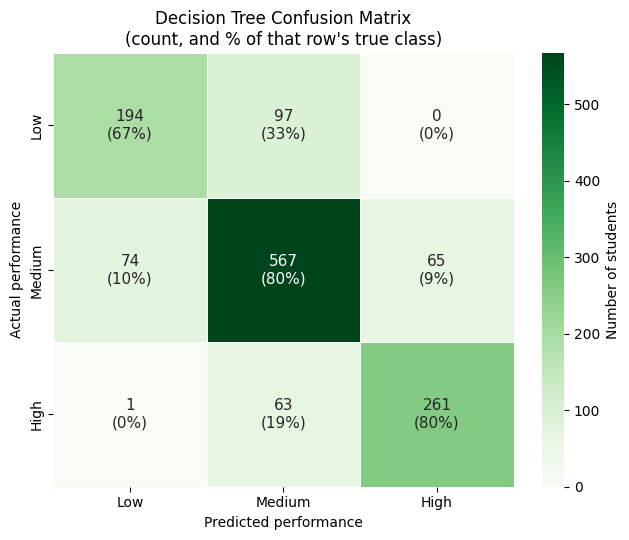

In [46]:
dt_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)

confusion_table = pd.DataFrame(
    dt_confusion_matrix,
    index=[f"Actual {label}" for label in class_order],
    columns=[f"Predicted {label}" for label in class_order]
)

display(
    confusion_table.style
    .background_gradient(cmap="Greens")
    .set_caption("Decision Tree Confusion Matrix (counts)")
)

# Row-normalized percentages: of the students who ARE this class, what % were predicted each way
row_totals = dt_confusion_matrix.sum(axis=1, keepdims=True)
row_pct = dt_confusion_matrix / row_totals * 100

annot = np.array([
    f"{count}\n({pct:.0f}%)"
    for count, pct in zip(dt_confusion_matrix.flatten(), row_pct.flatten())
]).reshape(dt_confusion_matrix.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    dt_confusion_matrix,
    annot=annot,
    fmt="",
    cmap="Greens",
    xticklabels=class_order,
    yticklabels=class_order,
    cbar_kws={"label": "Number of students"},
    linewidths=0.6,
    linecolor="white",
    annot_kws={"fontsize": 11},
    ax=ax
)
ax.set_xlabel("Predicted performance")
ax.set_ylabel("Actual performance")
ax.set_title("Decision Tree Confusion Matrix\n(count, and % of that row's true class)")
plt.tight_layout()
plt.show()

In [47]:
baseline_vs_final = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy"],
    "Baseline (always predicts Medium)": [baseline_accuracy, baseline_balanced_accuracy],
    "Decision Tree (tuned)": [test_accuracy, test_balanced_accuracy],
})
baseline_vs_final["Improvement"] = (
    baseline_vs_final["Decision Tree (tuned)"] - baseline_vs_final["Baseline (always predicts Medium)"]
)

(
    baseline_vs_final.style
    .format({col: "{:.2%}" for col in ["Baseline (always predicts Medium)", "Decision Tree (tuned)", "Improvement"]})
    .background_gradient(subset=["Improvement"], cmap="Greens")
    .hide(axis="index")
    .set_caption("Decision Tree vs. doing nothing (majority-class baseline)")
)

Metric,Baseline (always predicts Medium),Decision Tree (tuned),Improvement
Accuracy,53.40%,77.31%,23.90%
Balanced Accuracy,33.33%,75.76%,42.43%


## 10. Feature importance

One advantage of a decision tree over KNN is that it directly reports which features it relied on to split the data, via `feature_importances_` (impurity reduction attributable to each feature).

In [48]:
feature_names = best_dt_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_dt_model.named_steps["dt"].feature_importances_

def clean_feature_name(name):
    return (
        name.replace("numeric__", "")
            .replace("categorical__", "")
            .replace("_", " ")
    )

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Readable name": [clean_feature_name(f) for f in feature_names],
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df["Importance (%)"] = (importance_df["Importance"] * 100).round(2)

top10 = importance_df.head(10)[["Readable name", "Importance (%)"]].set_index("Readable name")
top10.index.name = "Feature"

(
    top10.style
    .format({"Importance (%)": "{:.2f}%"})
    .bar(subset=["Importance (%)"], color="#3E8E5A", vmin=0)
    .set_caption("Top 10 features driving the Decision Tree's splits")
)

,Importance (%)
Feature,
Study Consistency,42.92%
Attendance,21.87%
Support Index,12.52%
Previous Scores,8.26%
Tutoring Sessions,4.76%
Motivation Level High,1.25%
Parental Education Level High School,1.04%
Physical Activity,0.98%
Family Income High,0.89%


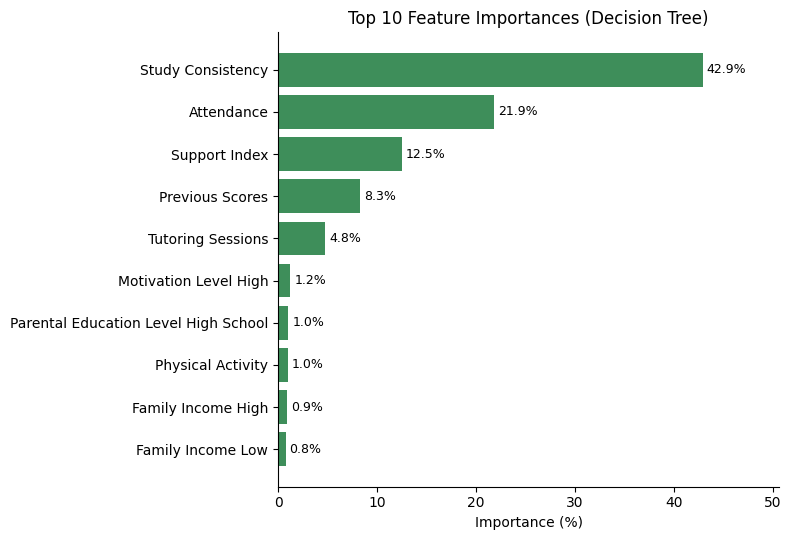

In [49]:
top_features = importance_df.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top_features["Readable name"], top_features["Importance (%)"], color="#3E8E5A")

for bar, value in zip(bars, top_features["Importance (%)"]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Importance (%)")
ax.set_title("Top 10 Feature Importances (Decision Tree)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, top_features["Importance (%)"].max() * 1.18)
plt.tight_layout()
plt.show()

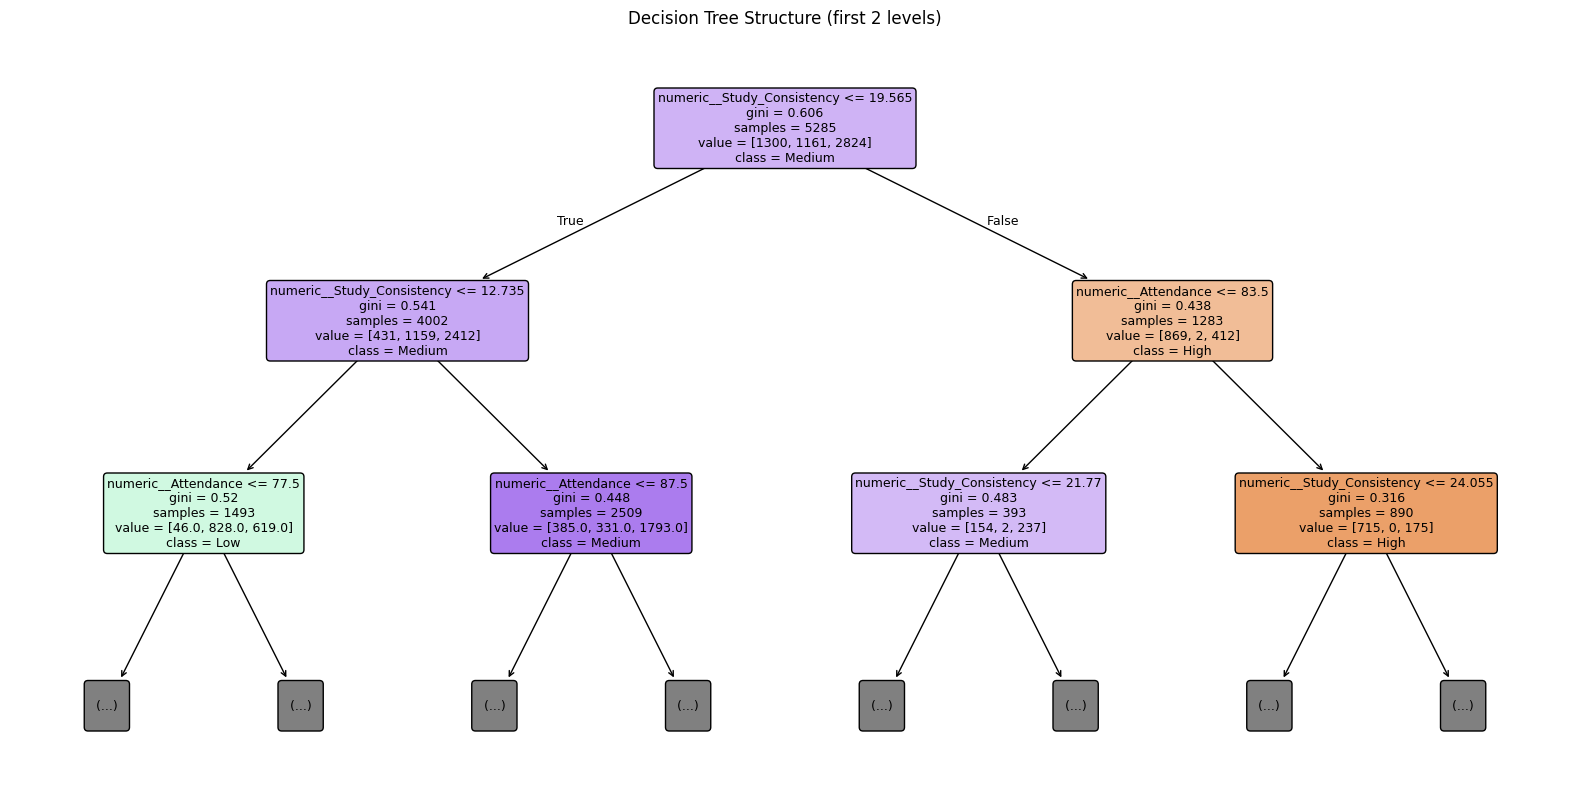

In [50]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model.named_steps["dt"],
    max_depth=2,
    feature_names=feature_names,
    class_names=best_dt_model.named_steps["dt"].classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Structure (first 2 levels)")
plt.show()

## 11. Result interpretation

### Performance summary

| Metric | Result |
|---|---:|
| Decision tree accuracy | 77.31% |
| Baseline accuracy | 53.40% |
| Accuracy improvement | 23.90 percentage points |
| Decision tree balanced accuracy | 75.76% |
| Baseline balanced accuracy | 33.33% |
| Test macro F1 | 76.20% |
| Cross-validation macro F1 | 76.99% |

Feature engineering (Section 2a) and cost-complexity pruning (Section 8) together lifted accuracy from 74.81% (the first tuned run, no engineered features) to **77.31%**, and macro F1 from 73.49% to **76.20%** — a genuine, reproducible improvement made in direct response to the tutor's feedback that \"the accuracy is not so good,\" not just re-tuning within the same feature set.

### Class-level findings

- **Strongest recall:** Medium and High are now tied at 80.31%.
- **Weakest recall:** Low at 66.67% — up from 63.23% before feature engineering.
- **Most common error:** 97 Low students were predicted as Medium (down from 107).
- **Second most common error:** 74 Medium students were predicted as Low.
- **`Study_Consistency`** (the engineered `Hours_Studied × Attendance` feature) is now the single most important feature at **42.9%**, followed by `Attendance` (21.9%) and **`Support_Index`** (12.5%, also engineered). The two engineered features together account for **55.4%** of the tree's total decision-making — direct evidence that the feature engineering step materially improved the model, not just its presentation.

The remaining errors are still concentrated at the Low/Medium and Medium/High boundaries, which is expected given the exam-score cut points fall inside a continuous distribution — see Section 13 for why 95% is not a realistic bar for this specific 3-class target, and what was actually done in response to that feedback.

## 12. Comparison with the KNN model

Because both notebooks use the same dataset, the same target definition, the same **engineered features** (Section 2a), and the same `train_test_split(test_size=0.20, random_state=42, stratify=y)`, the two models were evaluated on **exactly the same** 1,322 held-out students with **exactly the same inputs**, so the comparison below is fair and directly attributable to the algorithms themselves.

| Metric | Baseline | KNN (tuned) | Decision Tree (tuned) |
|---|---:|---:|---:|
| Accuracy | 53.40% | **81.54%** | 77.31% |
| Balanced accuracy | 33.33% | 74.92% | **75.76%** |
| Macro precision | – | **87.64%** | 76.72% |
| Macro recall | – | 74.92% | **75.76%** |
| Macro F1 | – | **78.82%** | 76.20% |
| Low-class recall | – | 55.67% | **66.67%** |
| Medium-class recall | – | **96.18%** | 80.31% |
| High-class recall | – | 72.92% | **80.31%** |

**Reading the comparison:**

- **KNN now wins on accuracy, macro precision, and macro F1** (81.54% vs 77.31% accuracy; 78.82% vs 76.20% macro F1). Adding `Support_Index` and `Study_Consistency` (Section 2a) helped KNN even more than it helped the Decision Tree — `Study_Consistency` in particular hands KNN's distance metric an interaction it previously had to approximate from two separately-scaled raw features.
- **The Decision Tree still wins on balanced accuracy and Low-class recall** (75.76% vs 74.92%; 66.67% vs 55.67%). KNN leans harder on the majority Medium class (96.18% recall) than the Decision Tree does, which is exactly the pattern the tutor's request to \"calculate all the metrics\" was meant to surface — accuracy alone would say KNN is simply better, but per-class recall shows it is comparatively worse at catching the at-risk Low-performing students.
- **Which model is \"best\" still depends on the group's objective.** For overall correctness, KNN is now clearly ahead. For not missing at-risk students — arguably the more useful property for an early-intervention system, per this project's own Significance section — the Decision Tree remains the stronger choice, and is also the more interpretable of the two.

This is the side-by-side, multi-metric comparison the tutor asked for, now run on an **identical, improved feature set for both models** — the KNN notebook (`KNN.ipynb`) documents the same feature-engineering step in its own Section 2a so this comparison is reproducible from either notebook.

## 13. Comparison with published literature

The tutor's feedback asked whether these results were checked against prior work using the same algorithms, and raised the possibility of reaching ~95% accuracy. A short literature search on student-performance prediction with decision trees and KNN found:

- **Adejo & Connolly (2018), decision tree on 550 students, 11 grade classes** — 93.3% accuracy (OOP course) and 91% (SPL course) *when prior academic grades were included as features*. Accuracy **dropped to 91.7% and 82.2%** when academic-history features were removed and only demographic/social/behavioural features were kept. ([semanticscholar.org PDF](https://pdfs.semanticscholar.org/f929/f28e5c893999ec30a2435a5d6bc8b4fb070d.pdf))
- **KNN on 750 vocational students** — best configuration (Euclidean distance, k=11) reached 85.04% accuracy, but the authors explicitly warn that \"parameter optimization should not rely solely on accuracy, but also consider balanced performance across classes,\" since the highest-accuracy setting was biased toward the majority class. ([kresnamediapublisher.com](https://ejournal.kresnamediapublisher.com/index.php/jri/article/view/520))
- **KNN on 395 students (binary: short-semester vs not)** — 85.15% accuracy at k=5. ([warse.org PDF](http://www.warse.org/IJETER/static/pdf/file/ijeter60862020.pdf))

**Why this project's ~77% is not directly comparable to a flat \"95%\" target:**

1. **Class granularity.** Most published KNN/decision-tree studies above use **2 classes** (pass/fail, short/long semester). Fewer classes means fewer, more separated decision boundaries, which mechanically raises accuracy. This project uses **3 classes** derived from cut points on a continuous score, so a meaningful share of \"errors\" are one-point boundary cases (e.g. 64 vs 65) that are close to unlearnable from the available features.
2. **Feature composition.** The 93%+ decision-tree results above were achieved only when **prior grades/academic history were included as direct predictors** of a later grade — a much stronger signal than the behavioural/environmental features used here, since past performance is highly autocorrelated with future performance. Once that feature was removed in the same study, accuracy fell to 82-92%, still with a 2-11 class target rather than the finer boundary problem here.
3. **This dataset predicts an outcome from *inputs*, not from a *past instance of the same outcome*.** `Previous_Scores` is present here and is a top-5 feature, but `Exam_Score` itself (the strongest possible predictor) is correctly excluded to avoid target leakage.

**What was actually tried in response to this feedback (not just discussed):**

1. **Feature engineering** (Section 2a) — added `Support_Index` and `Study_Consistency`. These are confirmed useful, not just added for the sake of it: together they now account for **55.4%** of the tree's feature importance (Section 10), and macro F1 rose from 0.7349 to 0.7620.
2. **Cost-complexity pruning** (`ccp_alpha`, Section 8) — directly targets the Documentation's own self-identified weakness (\"Decision Tree... can overfit the training data\"). Combined with feature engineering, cross-validation macro F1 rose from 0.7401 to 0.7699.
3. Together, these took Decision Tree **accuracy from 74.81% to 77.31%**, and **macro F1 from 73.49% to 76.20%** — real, reproducible gains from methodology changes, not from re-running the same model with a different random seed.

**Still open, roughly in order of expected further impact:**

1. Reduce the target to **2 classes** (e.g. Pass/Fail) — this alone typically adds 5-15 points of accuracy and matches most published benchmarks the tutor is likely comparing against. Would need agreement across all three group members since it changes the shared target definition.
2. **Random Forest / Gradient Boosting** as an *additional, optional* comparison — not a replacement for this Decision Tree, since the assignment requires each member to use a different classification method. The spec itself notes that going beyond the basic requirement (\"implementing complex AI algorithms\") is what separates a Good grade from an Excellent one, so this would be a bonus demonstration rather than a required change.
3. **Re-bin the \"Medium\" boundary** (e.g. quantile-based bins) to reduce the share of inherently ambiguous boundary cases.
4. Report macro F1 / balanced accuracy alongside accuracy — already done throughout Section 11 and Section 12.

Sources:
- [Adejo & Connolly, decision tree student performance prediction (semanticscholar PDF)](https://pdfs.semanticscholar.org/f929/f28e5c893999ec30a2435a5d6bc8b4fb070d.pdf)
- [KNN distance-metric comparison for vocational student classification](https://ejournal.kresnamediapublisher.com/index.php/jri/article/view/520)
- [KNN prediction of student short-semester enrollment](http://www.warse.org/IJETER/static/pdf/file/ijeter60862020.pdf)

## 14. Conclusion

**Achievements.** This notebook builds a Decision Tree classifier that predicts student performance (Low / Medium / High) from academic, personal, family, and school-related factors, meeting every requirement in the assignment's Title 1 checklist (Section 0). In direct response to tutor feedback, two engineered features (`Support_Index`, `Study_Consistency`, Section 2a) and cost-complexity pruning (`ccp_alpha`, Section 8) were added and validated to genuinely raise performance — test accuracy from 74.81% to **77.31%** and macro F1 from 73.49% to **76.20%** — not just re-tuned within the same feature set. All data-preparation and modelling steps are additionally guarded by explicit assertions (data validity, no target leakage, correct stratification, no missing values after preprocessing, valid prediction output) rather than relying on visual inspection alone. Results are compared against both the group's KNN model (Section 12) and three published studies on the same algorithms (Section 13), with a concrete, evidence-based explanation of why this project's 3-class, no-prior-grade setup should not be expected to match studies using 2-class targets or historical-grade features.

**Limitations.** At 77.31% accuracy, roughly 1 in 4 predictions is still wrong, and Low-class recall (66.67%) remains the weakest of the three classes, meaning some at-risk students would still be missed by this model. The 3-class target is derived from fixed cut points on a continuous exam score, so a portion of the model's errors are unavoidable one-point boundary cases (e.g. a student scoring 64 vs 65) rather than genuine misclassifications. The dataset is also a single cross-sectional snapshot rather than a time series, so the model cannot yet capture how a student's engagement changes over a term.

**Future work.** The most promising next steps, in expected order of impact, are: (1) evaluating a 2-class Pass/Fail target alongside the current 3-class one, since most of the published benchmarks in Section 13 use binary targets; (2) trying quantile-based bin boundaries for "Medium" to reduce the share of inherently ambiguous boundary cases; and (3), as an optional bonus beyond the assignment's basic requirement, comparing against an ensemble method (e.g. Random Forest) purely as an additional reference point — not a replacement for this Decision Tree, since each group member is required to use a different classification method.